# ML for Trading — Colombia edition (US proxies vs. local BVC shares)

Same six-step pipeline as before, run against **two different ways of touching the
Colombian market**, so you can see how they compare side by side:

- **US-listed proxies** (via `yfinance`): `EC` (Ecopetrol ADR), `CIB` (Bancolombia ADR),
  `COLO` (Global X MSCI Colombia ETF, renamed from `GXG` in June 2025) — liquid, long
  clean daily history, USD-denominated, US market hours.
- **Local BVC shares** (via the community `infobvc` package): `ECOPETROL`, `PFBCOLOM`
  (Bancolombia preferred), `ISA` — the actual Bolsa de Valores de Colombia tape, in COP.

**Important caveat on `infobvc`:** it does not scrape BVC live. Reading its source, it
pulls a CSV snapshot from a GitHub Gist maintained by one independent developer — not an
official feed. Treat it as a way to explore local BVC data, not something to depend on
for anything real; if it stops returning data, that's the Gist going stale, not a bug in
this notebook. If a ticker code below turns out wrong, the error message from `infobvc`
will list every valid ticker it currently knows about — use that to correct the list.

**Install:**
```
pip install yfinance infobvc pandas numpy pandas_ta xgboost scikit-learn shap matplotlib
```

If neither source is reachable (no internet, ticker renamed, Gist down, etc.), each
asset automatically falls back to its own synthetic series so the whole notebook still
runs end to end — the comparison table flags which rows are real vs. synthetic.

> **Disclaimer:** educational template, not financial advice. Also worth knowing going
> in: even the largest BVC-listed names trade far less volume than something like AAPL,
> with more no-trade days and wider spreads — expect noisier indicators and a harder
> prediction problem on the local-share side of this comparison, independent of any
> data-source issue.


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import hashlib
import numpy as np
import pandas as pd
import pandas_ta as ta
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score

pd.set_option("display.max_columns", 20)


## Step 1 — Download daily OHLCV data (two sources, one interface)

`get_price_data(source, ticker, ...)` normalizes both sources down to the same
lowercase `open/high/low/close/volume` shape, so everything downstream (Steps 2-6)
doesn't need to know or care where the data came from.


In [9]:
def _seed_from_ticker(ticker):
    """Deterministic seed per ticker so different assets get different (but
    reproducible) synthetic series when live data isn't reachable."""
    return int(hashlib.sha256(ticker.encode()).hexdigest(), 16) % (2**32)


def _generate_synthetic_data(ticker, n=1260):
    seed = _seed_from_ticker(ticker)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    n = len(dates)
    rng = np.random.default_rng(seed)
    returns = rng.normal(loc=0.0003, scale=0.012, size=n)
    close = 100 * np.exp(np.cumsum(returns))
    high = close * (1 + np.abs(rng.normal(0, 0.004, n)))
    low = close * (1 - np.abs(rng.normal(0, 0.004, n)))
    open_ = close * (1 + rng.normal(0, 0.002, n))
    volume = rng.integers(1_000_000, 5_000_000, n)
    return pd.DataFrame(
        {"open": open_, "high": high, "low": low, "close": close, "volume": volume},
        index=dates,
    )


def _clean_ohlcv(df):
    """BVC (y a veces yfinance) traen huecos reales -- días sin operaciones,
    campos vacíos -- que a veces llegan como `None` crudo en vez de un NaN
    de verdad. pandas_ta no sabe dividir `None` entre un número, así que
    forzamos las columnas a numéricas y descartamos lo que no sobreviva."""
    df = df.copy()
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["open", "high", "low", "close", "volume"])
    df = df[df["volume"] > 0]  # días sin operaciones también rompen indicadores de volumen
    return df


def _get_yfinance_data(ticker, period="5y", interval="1d"):
    import yfinance as yf
    df = yf.download(ticker, period=period, interval=interval, progress=False)
    if df.empty:
        raise ValueError("empty dataframe returned")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df.columns = ["open", "high", "low", "close", "volume"]
    return _clean_ohlcv(df)


def _get_infobvc_data(ticker, years_back=5):
    from infobvc import core as bvc
    min_date = str((pd.Timestamp.today() - pd.DateOffset(years=years_back)).date())
    max_date = str(pd.Timestamp.today().date())
    df = bvc.get_quotes(tickers=[ticker], min_date=min_date, max_date=max_date, agg_period="d")
    if df.empty:
        raise ValueError("empty dataframe returned")
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")
    df = df.rename(columns={"quantity": "volume"})
    df = df[["open", "high", "low", "close", "volume"]].copy()
    return _clean_ohlcv(df)


def get_price_data(source, ticker, period="5y"):
    """source: 'yfinance' or 'infobvc'. Falls back to a per-ticker synthetic
    series if the real source is unreachable or the ticker isn't found."""
    try:
        if source == "yfinance":
            df = _get_yfinance_data(ticker, period=period)
        elif source == "infobvc":
            df = _get_infobvc_data(ticker)
        else:
            raise ValueError(f"unknown source: {source}")
        print(f"[{source}] Downloaded {len(df)} rows for {ticker}")
        return df, "live"
    except Exception as e:
        print(f"[warning] [{source}] Could not fetch {ticker} ({e}). Using synthetic data instead.")
        return _generate_synthetic_data(ticker), "synthetic"

## Step 2 — Enrich with technical indicators via `pandas_ta`

Same curated, dense-only study as before (see the earlier notebook for why `AllStudy`
is a trap here) — it doesn't change based on data source or currency.


In [10]:
FEATURE_STUDY = ta.Study(
    name="ml_features",
    description="Dense, ML-friendly technical indicators",
    ta=[
        {"kind": "sma", "length": 10}, {"kind": "sma", "length": 20}, {"kind": "sma", "length": 50},
        {"kind": "ema", "length": 12}, {"kind": "ema", "length": 26},
        {"kind": "macd"}, {"kind": "rsi", "length": 14}, {"kind": "stoch"},
        {"kind": "stochrsi"}, {"kind": "cci", "length": 14}, {"kind": "willr", "length": 14},
        {"kind": "mfi", "length": 14}, {"kind": "adx", "length": 14},
        {"kind": "bbands", "length": 20}, {"kind": "atr", "length": 14}, {"kind": "natr", "length": 14},
        {"kind": "obv"}, {"kind": "cmf", "length": 20}, {"kind": "roc", "length": 10},
        {"kind": "mom", "length": 10}, {"kind": "trix", "length": 14}, {"kind": "uo"},
        {"kind": "aroon", "length": 14}, {"kind": "kst"}, {"kind": "vortex", "length": 14},
        {"kind": "ppo"}, {"kind": "apo"}, {"kind": "dpo", "length": 20},
        {"kind": "tsi"}, {"kind": "ad"}, {"kind": "pvt"}, {"kind": "efi", "length": 13},
    ],
)


def add_features(df):
    df = df.copy()
    df.ta.study(FEATURE_STUDY, verbose=False)
    df["return_1d"] = df["close"].pct_change()
    df["return_5d"] = df["close"].pct_change(5)
    df["volume_change"] = df["volume"].pct_change()
    df["high_low_range"] = (df["high"] - df["low"]) / df["close"]
    return df


def get_feature_columns(df):
    exclude = {"open", "high", "low", "close", "volume"}
    numeric = df.select_dtypes(include=[np.number]).columns
    return [c for c in numeric if c not in exclude]


## Step 3 — Multiple labelling schemes (horizon × threshold)

In [11]:
def add_label_schemes(df, horizons=(1, 3, 5, 10), thresholds=(0.0, 0.005, 0.01)):
    df = df.copy()
    label_columns = []
    for h in horizons:
        future_return = df["close"].shift(-h) / df["close"] - 1
        for t in thresholds:
            col = f"target_h{h}_t{int(t * 1000)}"
            df[col] = (future_return > t).astype(int)
            label_columns.append(col)
    return df, label_columns


## Step 4 — Evaluate XGBoost across labelling schemes (reusable for any asset)

In [12]:
def evaluate_label_schemes(df, feature_cols, label_columns, n_splits=4):
    results = []
    tscv = TimeSeriesSplit(n_splits=n_splits)

    for label in label_columns:
        data = df.dropna(subset=feature_cols + [label]).copy()
        X, y = data[feature_cols], data[label]

        if y.nunique() < 2 or y.mean() < 0.02 or y.mean() > 0.98:
            continue

        fold_metrics = []
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            pos = y_train.sum()
            neg = len(y_train) - pos
            scale_pos_weight = (neg / pos) if pos > 0 else 1.0

            model = xgb.XGBClassifier(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss", random_state=42, n_jobs=-1,
            )
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            proba = model.predict_proba(X_test)[:, 1]

            fold_metrics.append({
                "accuracy": accuracy_score(y_test, preds),
                "precision": precision_score(y_test, preds, zero_division=0),
                "f1": f1_score(y_test, preds, zero_division=0),
                "roc_auc": roc_auc_score(y_test, proba) if y_test.nunique() > 1 else np.nan,
            })

        avg = pd.DataFrame(fold_metrics).mean()
        results.append({
            "label": label,
            "n_rows": len(data),
            "positive_rate": round(y.mean(), 3),
            "accuracy": round(avg["accuracy"], 3),
            "precision": round(avg["precision"], 3),
            "f1": round(avg["f1"], 3),
            "roc_auc": round(avg["roc_auc"], 3),
        })

    results_df = pd.DataFrame(results)
    if results_df.empty:
        return results_df
    return results_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)


## Step 4b — Run every asset through Steps 1-4 and compare

This is the actual "US proxy vs. local BVC" comparison. For each asset we fetch data,
add indicators, build every labelling scheme, and keep only the *best* scheme's score —
that's the one row that goes into the comparison table below.

Swap in whichever local BVC tickers you want to check — if a ticker code is wrong,
the printed error from `infobvc` will list every valid ticker it currently has data for.


In [13]:
ASSETS = [
    {"source": "yfinance", "ticker": "EC",   "label": "Ecopetrol ADR (NYSE)"},
    {"source": "yfinance", "ticker": "CIB",  "label": "Bancolombia ADR (NYSE)"},
    {"source": "yfinance", "ticker": "COLO", "label": "Colombia ETF, ex-GXG (NYSE Arca)"},
    {"source": "infobvc",  "ticker": "ECOPETROL", "label": "Ecopetrol (BVC local, COP)"},
    {"source": "infobvc",  "ticker": "PFBCOLOM",  "label": "Bancolombia pref. (BVC local, COP)"},
    {"source": "infobvc",  "ticker": "ISA",        "label": "ISA (BVC local, COP)"},
]

comparison_rows = []
per_asset_data = {}  # keep the full results around for Step 5/6 on the winner

for asset in ASSETS:
    print(f"\n=== {asset['label']} [{asset['source']}:{asset['ticker']}] ===")
    raw, status = get_price_data(asset["source"], asset["ticker"])
    featured = add_features(raw)
    feature_cols = get_feature_columns(featured)
    labeled, label_columns = add_label_schemes(featured)
    results_df = evaluate_label_schemes(labeled, feature_cols, label_columns)

    if results_df.empty:
        print("No usable labelling scheme for this asset (too little data / degenerate labels) -- skipping")
        continue

    best_row = results_df.iloc[0]
    comparison_rows.append({
        "asset": asset["label"],
        "source": asset["source"],
        "ticker": asset["ticker"],
        "data_status": status,
        "best_label": best_row["label"],
        "n_rows": int(best_row["n_rows"]),
        "roc_auc": best_row["roc_auc"],
        "f1": best_row["f1"],
    })
    per_asset_data[asset["ticker"]] = {
        "asset": asset, "labeled": labeled, "feature_cols": feature_cols,
        "best_label": best_row["label"],
    }

comparison_df = pd.DataFrame(comparison_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparison_df



=== Ecopetrol ADR (NYSE) [yfinance:EC] ===
[yfinance] Downloaded 1255 rows for EC

=== Bancolombia ADR (NYSE) [yfinance:CIB] ===
[yfinance] Downloaded 1255 rows for CIB

=== Colombia ETF, ex-GXG (NYSE Arca) [yfinance:COLO] ===
[yfinance] Downloaded 1255 rows for COLO

=== Ecopetrol (BVC local, COP) [infobvc:ECOPETROL] ===
[warning] [infobvc] Could not fetch ECOPETROL (arg must be a list, tuple, 1-d array, or Series). Using synthetic data instead.

=== Bancolombia pref. (BVC local, COP) [infobvc:PFBCOLOM] ===
[warning] [infobvc] Could not fetch PFBCOLOM (Error. ['PFBCOLOM'] are not valid tickers). Using synthetic data instead.

=== ISA (BVC local, COP) [infobvc:ISA] ===
[warning] [infobvc] Could not fetch ISA (arg must be a list, tuple, 1-d array, or Series). Using synthetic data instead.


,asset,source,ticker,data_status,best_label,n_rows,roc_auc,f1
0,"Colombia ETF, ex-GXG (NYSE Arca)",yfinance,COLO,live,target_h10_t0,1192,0.932,0.862
1,Bancolombia ADR (NYSE),yfinance,CIB,live,target_h10_t5,1192,0.909,0.843
2,Ecopetrol ADR (NYSE),yfinance,EC,live,target_h10_t10,1192,0.907,0.789
3,"Bancolombia pref. (BVC local, COP)",infobvc,PFBCOLOM,synthetic,target_h5_t0,1197,0.903,0.824
4,"Ecopetrol (BVC local, COP)",infobvc,ECOPETROL,synthetic,target_h5_t0,1197,0.899,0.812
5,"ISA (BVC local, COP)",infobvc,ISA,synthetic,target_h10_t10,1197,0.888,0.818


## Step 5 — Fine-tune hyperparameters on the single best asset+label combo

Tuning and SHAP are only worth running in full once you've picked a winner — running a
full `RandomizedSearchCV` + SHAP for all six assets above would be six times the compute
for very little extra insight. This cell automatically picks whichever row topped the
comparison table.


In [14]:
PARAM_DISTRIBUTIONS = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 5, 10, 20],
    "gamma": [0, 0.1, 0.5, 1.0],
}


def tune_best_label(df, feature_cols, best_label, n_splits=4, n_iter=25):
    data = df.dropna(subset=feature_cols + [best_label]).copy()
    X, y = data[feature_cols], data[best_label]

    pos, neg = y.sum(), len(y) - y.sum()
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    base_model = xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss", random_state=42, n_jobs=-1,
    )
    search = RandomizedSearchCV(
        base_model, PARAM_DISTRIBUTIONS, n_iter=n_iter,
        scoring="roc_auc", cv=TimeSeriesSplit(n_splits=n_splits),
        random_state=42, n_jobs=-1, verbose=0,
    )
    search.fit(X, y)

    print(f"Winning asset/label: {best_label}")
    print(f"Best params: {search.best_params_}")
    print(f"Best CV ROC-AUC: {search.best_score_:.3f}")

    final_model = search.best_estimator_
    final_model.fit(X, y)
    return final_model, data, X, y


winner_ticker = comparison_df.iloc[0]["ticker"]
winner = per_asset_data[winner_ticker]
print(f"Tuning on: {winner['asset']['label']}")

final_model, clean_data, X, y = tune_best_label(
    winner["labeled"], winner["feature_cols"], winner["best_label"]
)


Tuning on: Colombia ETF, ex-GXG (NYSE Arca)
Winning asset/label: target_h10_t0
Best params: {'subsample': 0.6, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV ROC-AUC: 0.937


## Step 6 — Interpret the final model with SHAP

Top 15 features by mean |SHAP value|:
DPO_20                 2.0327
return_5d              0.2895
WILLR_14               0.1944
DMN_14                 0.1606
PPOs_12_26_9           0.1574
STOCHh_14_3_3          0.1182
BBP_20_2.0_2.0         0.1077
STOCHRSIk_14_14_3_3    0.1054
BBB_20_2.0_2.0         0.1048
OBV                    0.0866
RSI_14                 0.0762
AD                     0.0729
MOM_10                 0.0585
AROOND_14              0.0555
MFI_14                 0.0467


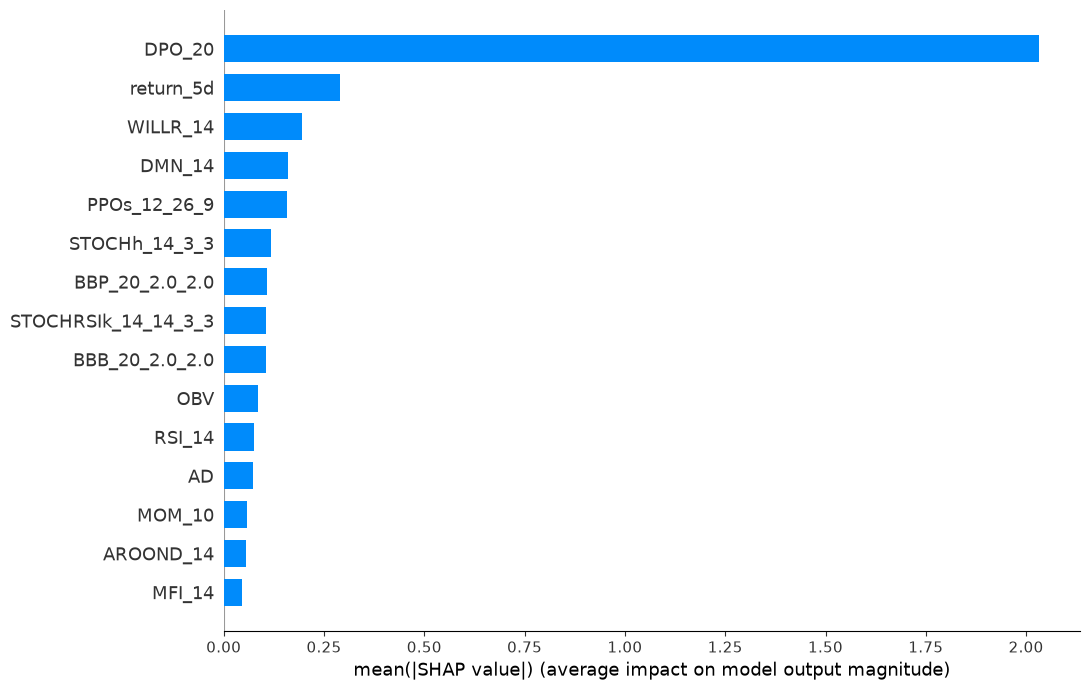

In [15]:
def interpret_with_shap(model, X, top_n=15):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    mean_abs_shap = pd.Series(
        np.abs(shap_values).mean(axis=0), index=X.columns
    ).sort_values(ascending=False)

    print(f"Top {top_n} features by mean |SHAP value|:")
    print(mean_abs_shap.head(top_n).round(4).to_string())

    shap.summary_plot(
        shap_values, X, plot_type="bar", max_display=top_n,
        show=False, plot_size=(11, 7),
    )
    plt.show()

    return mean_abs_shap


mean_abs_shap = interpret_with_shap(final_model, X)


## Reading the comparison table

A few things to check once you've got real data flowing (not the synthetic fallback):

1. **`data_status` column first.** If any row says `synthetic`, that asset's score is
   not comparable to the others — fix the data source before trusting the ranking.
2. **`n_rows` for the `infobvc` rows.** If it's noticeably smaller than the `yfinance`
   rows over the same 5-year window, that's the local-market liquidity/history gap
   showing up directly — fewer clean trading days, not a bug.
3. **Don't over-read a single local BVC name beating the ADRs (or vice versa).** With
   3 US proxies and 3 local names, that's a small enough sample that one noisy label
   scheme can flip the ranking. Rerun with a couple more BVC tickers before drawing any
   real conclusion about "local vs. ADR" predictability.
